In [ ]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import os
import gc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl
from matplotlib import colors
from matplotlib.lines import Line2D

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def get_dotplot_df(adata, annotation_col, genes_for_plot, expression_cutoff=0, 
                   standard_var=False, standard_method='zscore',
                   cap=None, floor=None):
    # cap / floor are quantiles (e.g. cap=0.99, floor=0.01)

    import numpy as np
    import scipy.sparse as sp
    import pandas as pd
    from scipy.stats import zscore

    # filter the anndata by genes needed for plot
    ad = adata[:, adata.var_names.isin(genes_for_plot)].copy()

    # ensure dense matrix for manipulation
    X = ad.X.toarray() if sp.issparse(ad.X) else ad.X.copy()

    # --- NEW: apply per-gene clipping ---
    if cap is not None or floor is not None:
        for i, gene in enumerate(ad.var_names):
            gene_expr = X[:, i]

            if floor is not None:
                floor_value = np.quantile(gene_expr, floor)
            else:
                floor_value = gene_expr.min()

            if cap is not None:
                cap_value = np.quantile(gene_expr, cap)
            else:
                cap_value = gene_expr.max()

            X[:, i] = np.clip(gene_expr, floor_value, cap_value)

    # convert to df
    df = pd.DataFrame(
        X,
        index=[ad.obs['cell_id'], ad.obs[annotation_col]],
        columns=ad.var_names
    )

    # get mean per group
    group_mean = df.reset_index().drop('cell_id', axis=1)\
        .groupby(annotation_col, observed=True).mean()

    # normalise/standardise the group mean
    if standard_var:
        if standard_method == 'zscore':
            group_mean = group_mean.apply(zscore, axis=0)
        elif standard_method == 'minmax':
            group_mean = (group_mean - group_mean.min(axis=0)) / (
                group_mean.max(axis=0) - group_mean.min(axis=0)
            )

    # melt df for plotting
    group_mean = group_mean.melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature'])\
        .rename(columns={'value': 'mean'})

    # calculate cell fraction
    cell_fraction = (df > expression_cutoff).reset_index()\
        .drop('cell_id', axis=1)\
        .groupby(annotation_col, observed=True).sum().divide(
            df.reset_index().groupby(annotation_col, observed=True)['cell_id'].count(),
            axis=0
        )\
        .melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature'])\
        .rename(columns={'value': 'proportion'})

    # return concatenated mean and fraction
    return pd.concat([group_mean, cell_fraction], axis=1).reset_index()

reference_dir = '../../../data/GBM_LEAP_annotations/'
output_dir = '../../../data/EDFig10/'

In [ ]:
adata = sc.read_h5ad(os.path.join(reference_dir, 'GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad'))
adata = adata[adata.obs['annotation_coarse']=='Myeloid']
adata = adata[:,adata.var['feature_types']=='Gene Expression']

# normalise
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 500 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


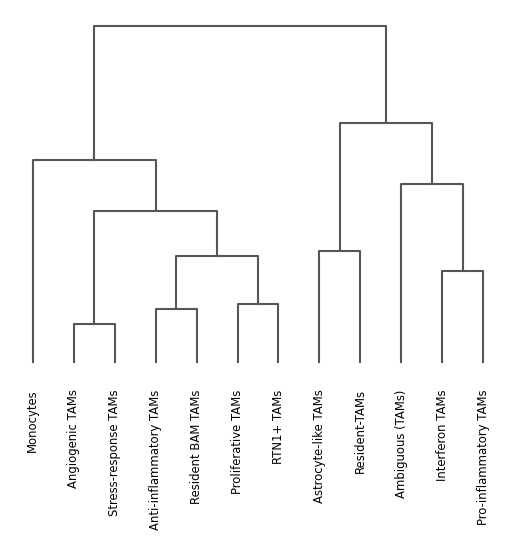

<Axes: >

In [ ]:
# hvg selection

adata_filtered = adata.copy()

sc.pp.highly_variable_genes(
    adata_filtered,
    n_top_genes=500,
    flavor = 'seurat_v3'
)
hvg = adata_filtered.var_names[adata_filtered.var["highly_variable"]]
adata_filtered = adata[:,adata.var_names.isin(hvg)]

# compute dendrogram
sc.tl.dendrogram(
    adata_filtered,
    groupby="annotation_granular",
)

sc.pl.dendrogram(
    adata_filtered,
    groupby="annotation_granular",
)

In [ ]:
paper_order = [
    "Resident-TAMs",
    "Astrocyte-like TAMs",
    "Pro-inflammatory TAMs",
    "Interferon TAMs",
    "RTN1+ TAMs",
    "Proliferative TAMs",
    "Resident BAM TAMs",
    "Anti-inflammatory TAMs",
    "Monocytes",
    "Stress-response TAMs",
    "Angiogenic TAMs",
]
paper_order = list(reversed(paper_order))

# Miller scores

In [ ]:
from scipy import stats

# get neftel scores
miller_score_list = []
modules = pd.read_csv('../data/metadata/myeloid/miller_et_al_signatures.tsv', sep = '\t')
for i in modules.columns:
    gene_list = modules[i].dropna().tolist()
    sc.tl.score_genes(adata, gene_list, score_name=i+'_score', use_raw=False)
    miller_score_list.append(i+'_score')

In [ ]:
miller_score_list = [
 'Microglia_score',
 'Systemic Inflammatory_score',
 'Microglial Inflammatory_score',
 'Complement Immunosuppressive_score',
 'Scavenger Immunosuppressive_score',
 'Hypoxia_score',
 'IFN Response_score',
 'HS-UPR_score',
 'G2-M_score',
 'G1-S_score']

In [ ]:
miller_scores = adata.obs[miller_score_list+['annotation_granular']]
miller_scores['miller_top'] = miller_scores[miller_score_list].idxmax(axis=1)
miller_scores = miller_scores.groupby('annotation_granular')['miller_top'].value_counts().reset_index()
miller_scores = miller_scores.pivot(index = 'annotation_granular', columns = 'miller_top', values = 'count')
miller_scores = miller_scores.divide(miller_scores.sum(axis=1), axis=0)

/tmp/ipykernel_800538/28850103.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miller_scores['miller_top'] = miller_scores[miller_score_list].idxmax(axis=1)
/tmp/ipykernel_800538/28850103.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  miller_scores = miller_scores.groupby('annotation_granular')['miller_top'].value_counts().reset_index()


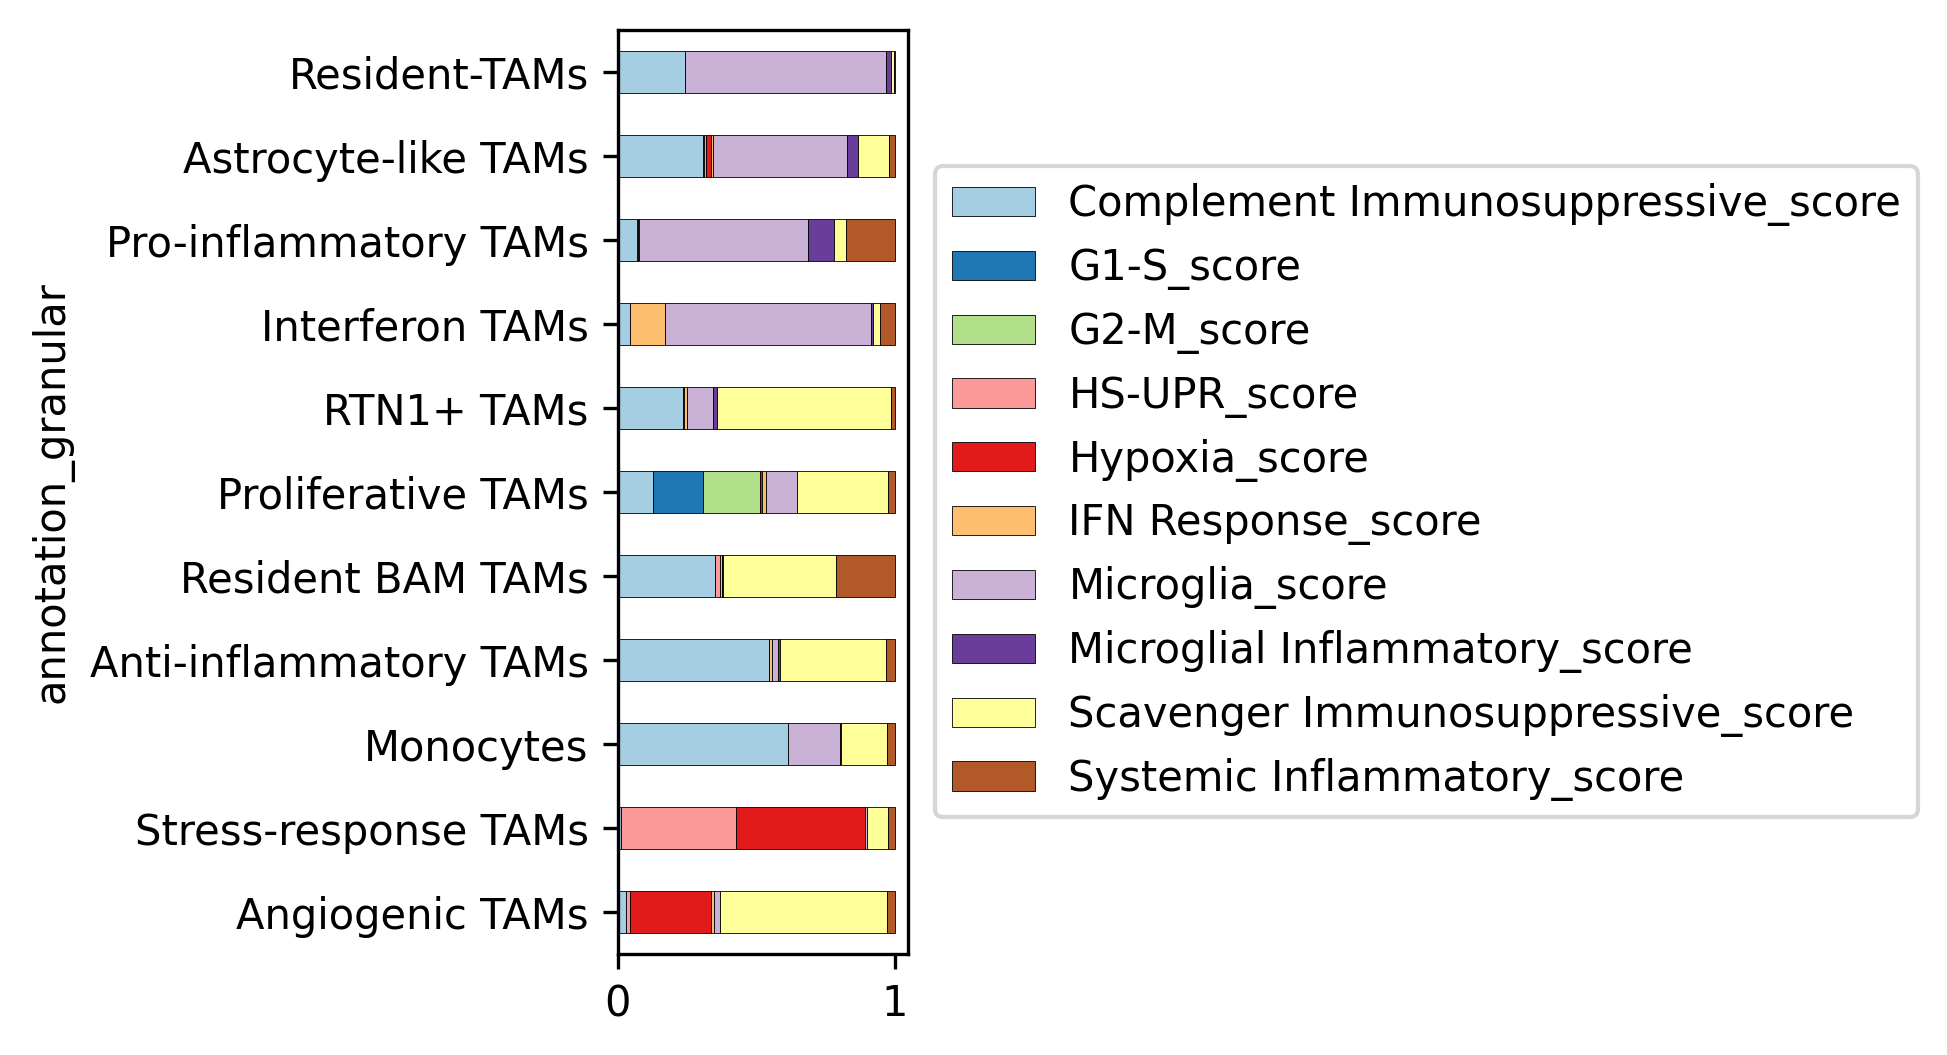

In [ ]:
miller_scores = miller_scores.reindex(paper_order)
ax = miller_scores.plot.barh(figsize=(1.25, 4), 
                             edgecolor="black",
                             linewidth=0.2,
                             cmap = 'Paired',
                             stacked=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig('../data/myeloid/EDFig10a2.pdf')

miller_scores.to_csv(f'{output_dir}/EDFig10a2.csv')

# Tumour composition

In [ ]:
tumour_comp = adata.obs.groupby('annotation_granular')['donor_id'].value_counts().reset_index()
tumour_comp = tumour_comp.pivot(index = 'annotation_granular', columns = 'donor_id', values = 'count')
tumour_comp = tumour_comp.divide(tumour_comp.sum(axis=1), axis=0)

/tmp/ipykernel_800538/3837109426.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tumour_comp = adata.obs.groupby('annotation_granular')['donor_id'].value_counts().reset_index()


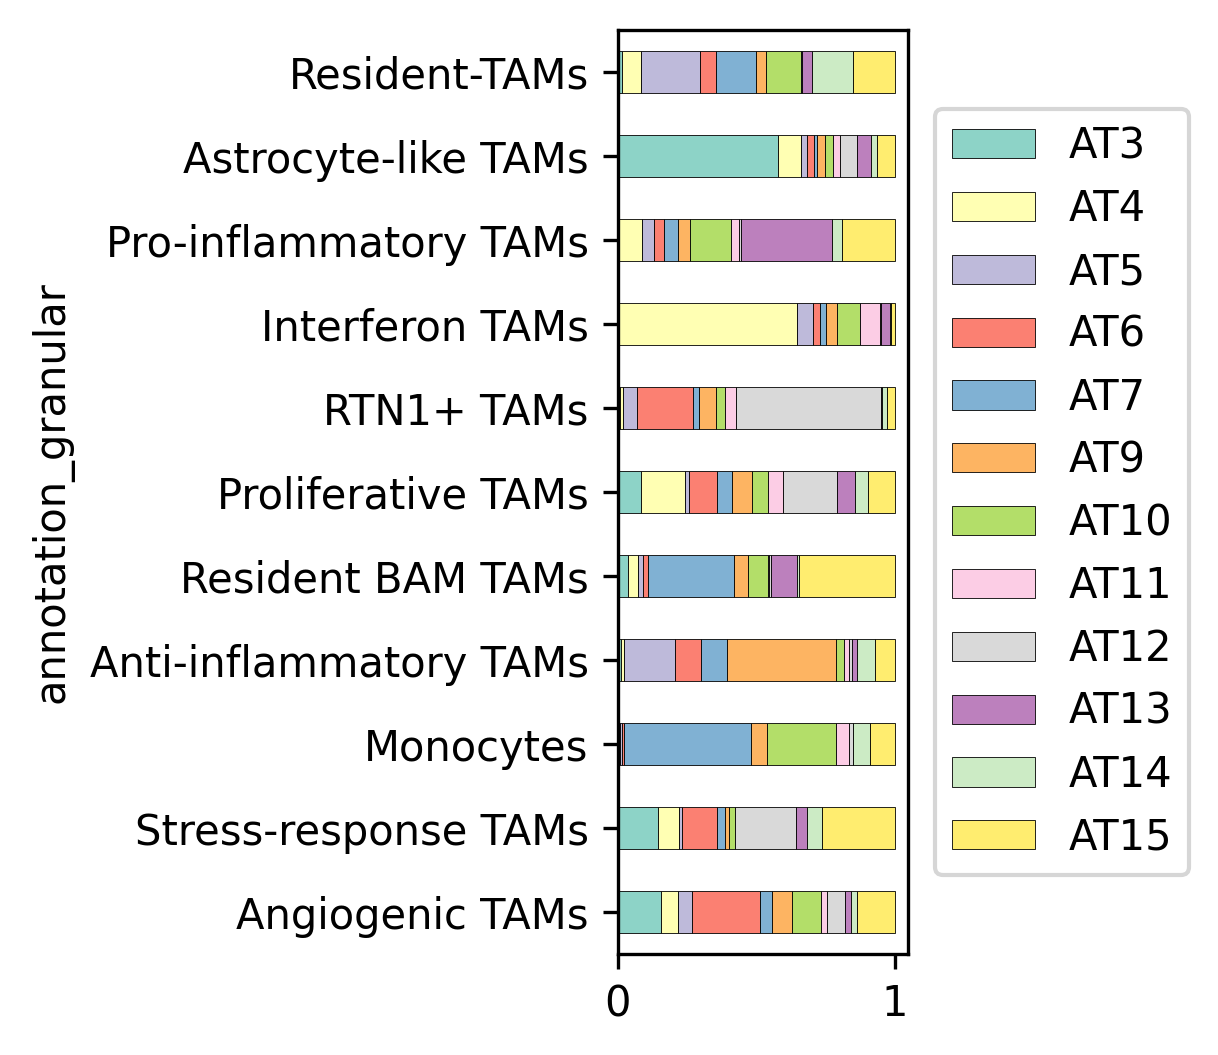

In [ ]:
tumour_comp = tumour_comp.reindex(paper_order)

ax = tumour_comp.plot.barh(figsize=(1.25, 4), 
                           edgecolor="black",
                           linewidth=0.2,
                           stacked=True,
                           cmap = 'Set3'
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig('../data/myeloid/EDFig10a1.pdf')

tumour_comp.to_csv(f'{output_dir}/EDFig10a1.csv')

# Gene expression

In [ ]:
genes = [
    "P2RY12",
    "CX3CR1",
    "CSF1R",
    "RTN1",
    "CD163",
    "FCGR3A",
    "CD14",
    "STAB1",
    "MRC1",
    "GPNMB",
    "VEGFA",
    "VCAN",
    "PLIN2",
]

In [ ]:
dp_df = get_dotplot_df(
    adata[adata.obs['annotation_granular'].isin(paper_order)],
    'annotation_granular',
    genes,
    standard_var=True,
    standard_method='zscore',
    cap=1,
    floor=0
)

In [ ]:
paper_order = [
    "Resident-TAMs",
    "Astrocyte-like TAMs",
    "Pro-inflammatory TAMs",
    "Interferon TAMs",
    "RTN1+ TAMs",
    "Proliferative TAMs",
    "Resident BAM TAMs",
    "Anti-inflammatory TAMs",
    "Monocytes",
    "Stress-response TAMs",
    "Angiogenic TAMs",
]

dp_df["annotation_granular"] = pd.Categorical(
    dp_df["annotation_granular"],
    categories=paper_order,
    ordered=True
)

dp_df["feature"] = pd.Categorical(
    dp_df["feature"],
    categories=genes,
    ordered=True
)

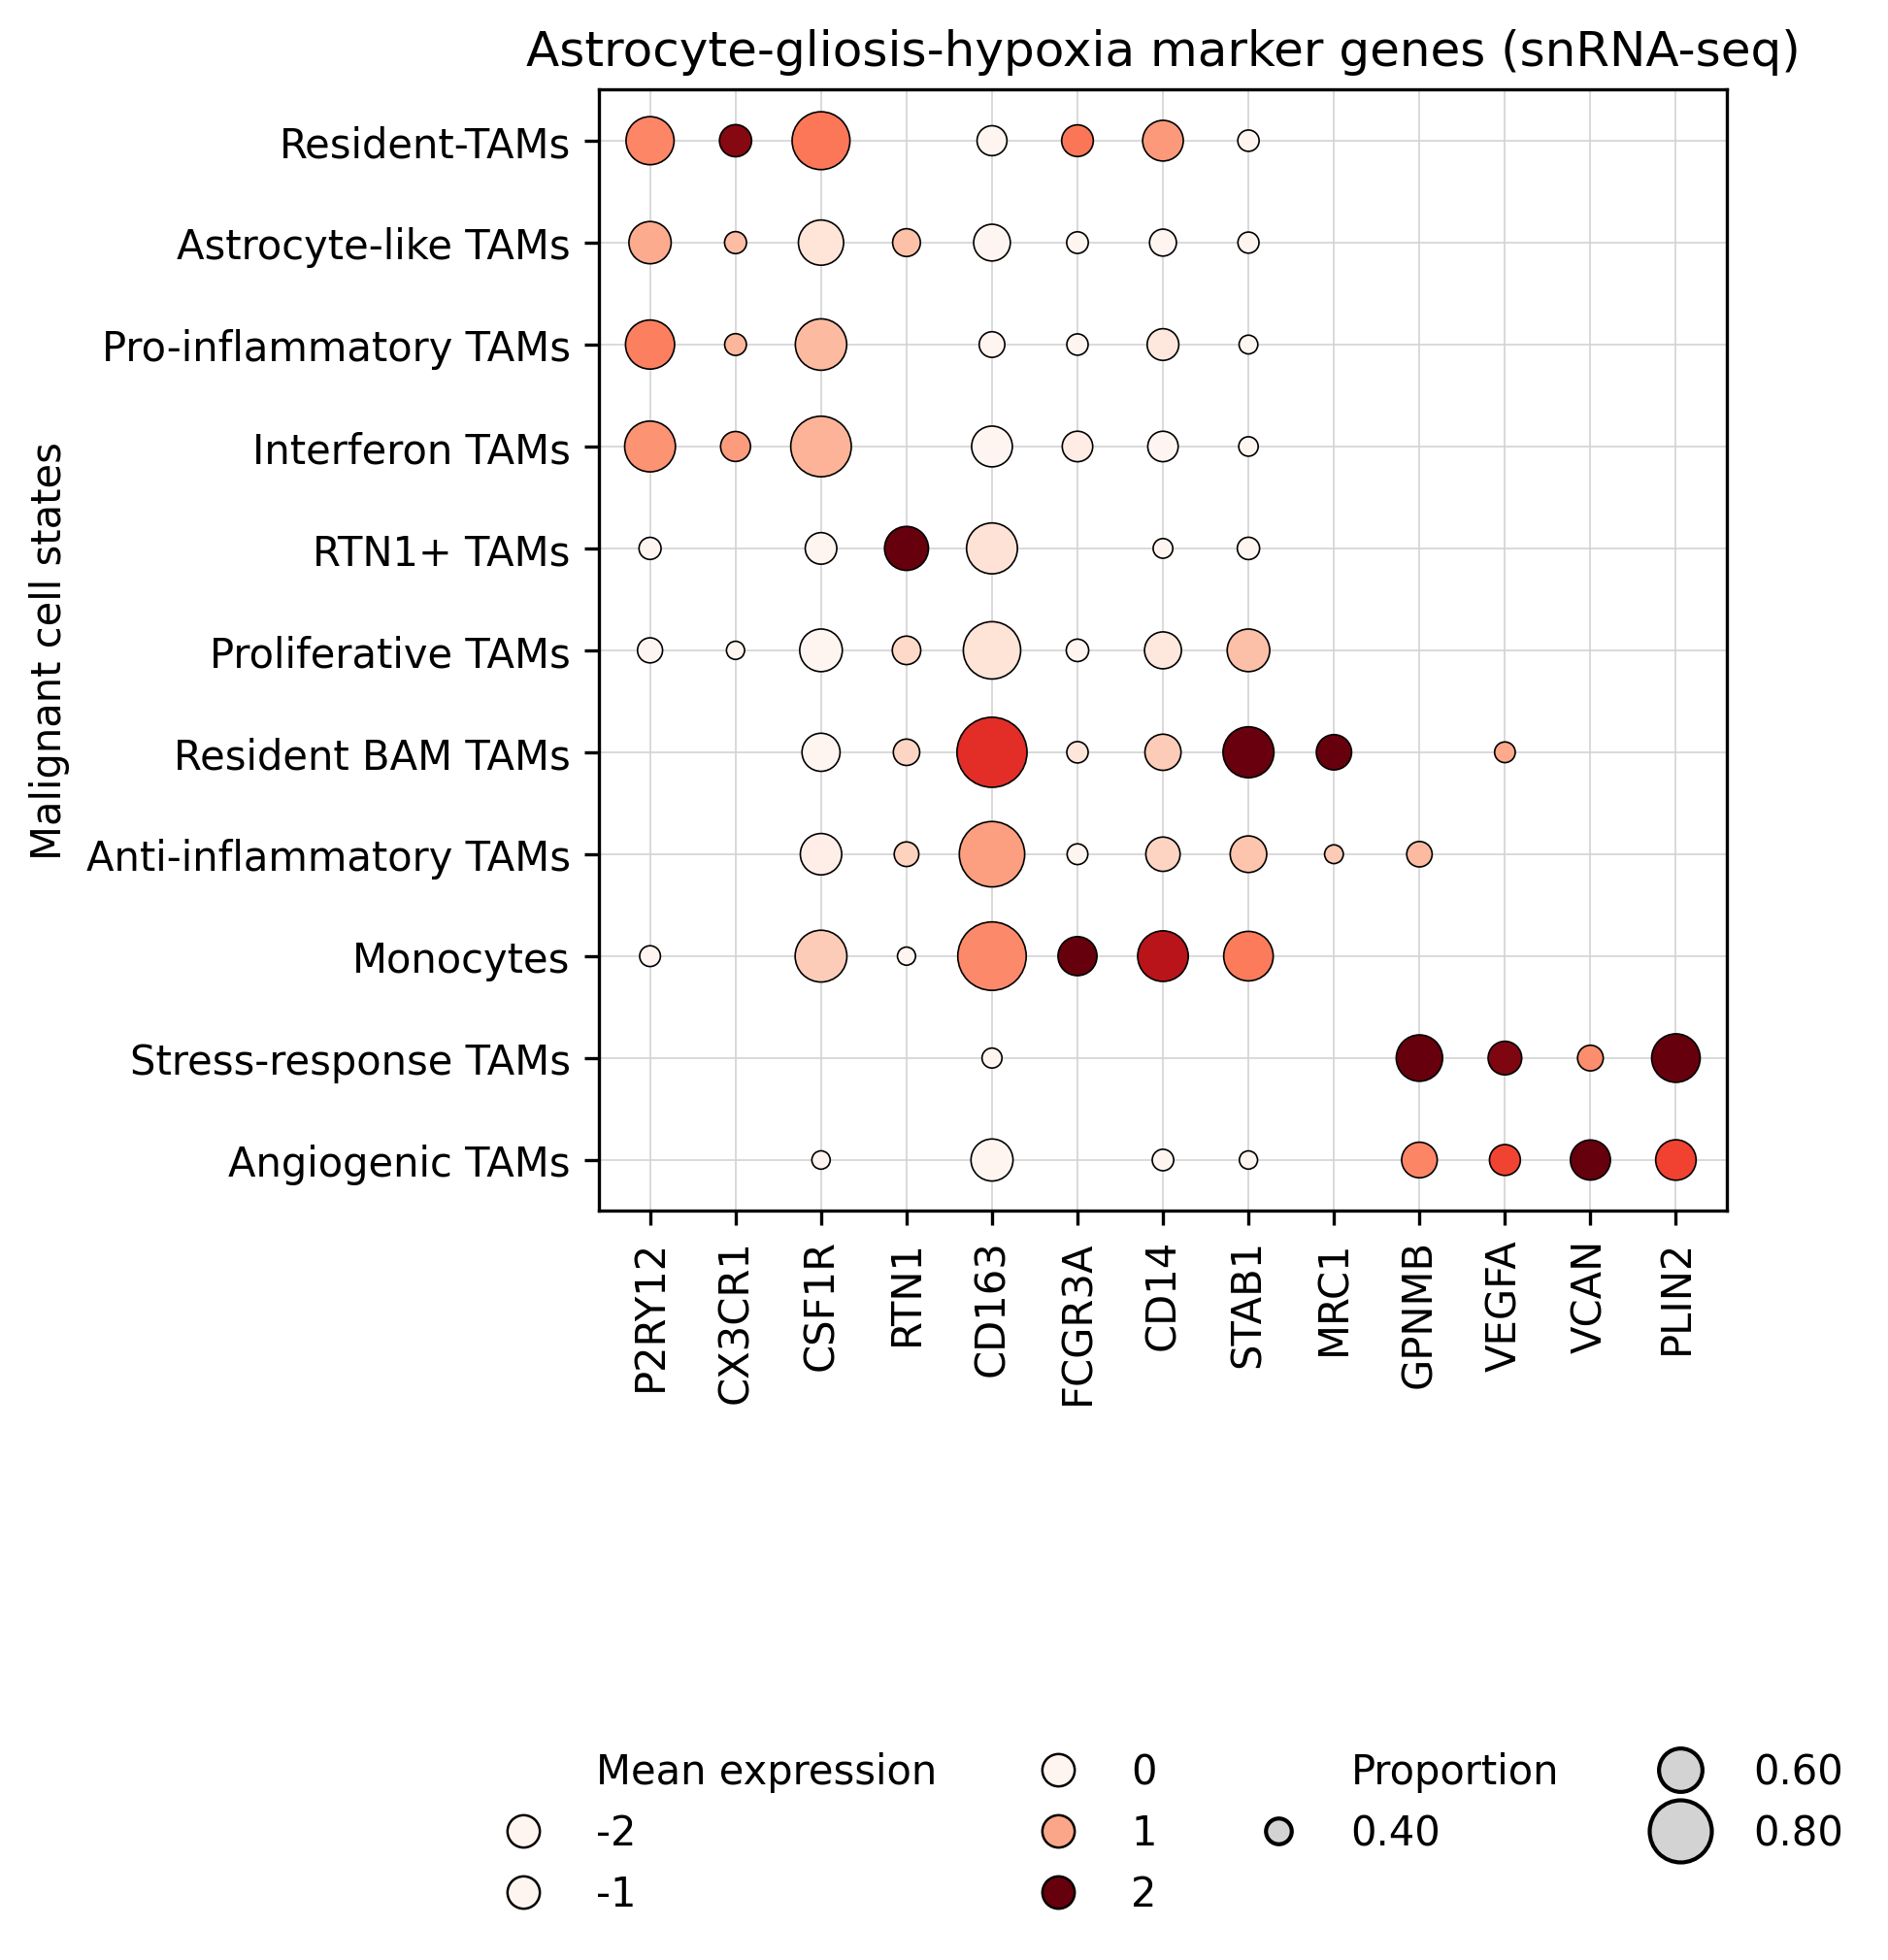

In [ ]:
# --- FILTER: drop low-proportion dots ---
dp_df_plot = dp_df[dp_df['proportion'] >= 0.25].copy()

# Color scaling
vmax = np.quantile(dp_df_plot['mean'], 0.99)
norm = colors.TwoSlopeNorm(vmin=0, vcenter=1.6, vmax=2)
cmap = plt.get_cmap('Reds')

# --- Dot-size scaling ---
size_min, size_max = 20, 300
pmin, pmax = dp_df_plot['proportion'].min(), dp_df_plot['proportion'].max()

prop_scaled = (dp_df_plot['proportion'] - pmin) / (pmax - pmin)
prop_scaled = np.clip(prop_scaled, 0, 1)
size_exp = 1.8

dp_df_plot['dot_area'] = size_min + (size_max - size_min) * (prop_scaled ** size_exp)

plt.figure(figsize=(5, 5))

ax = sns.scatterplot(
    data=dp_df_plot,
    x='feature',
    y='annotation_granular',
    hue='mean',
    size='dot_area',
    sizes=(size_min, size_max),
    palette='Reds',
    hue_norm=norm,
    edgecolor='black',
    linewidth=0.4,
    legend=False
)

# Grid lines
ax.set_axisbelow(True)
ax.grid(True, axis='x', color='lightgrey', linewidth=0.4)
ax.grid(True, axis='y', color='lightgrey', linewidth=0.4)

plt.xticks(rotation=90)
plt.title('Astrocyte-gliosis-hypoxia marker genes (snRNA-seq)')

# --- COLOR LEGEND ---
color_values = [-2, -1, 0, 1, 2]
color_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=8,
        markerfacecolor=cmap(norm(v)),
        markeredgecolor='black',
        markeredgewidth=0.6,
        label=f'{v:g}'
    )
    for v in color_values
]

# --- SIZE LEGEND ---
size_values = [0.4, 0.6, 0.8]
size_handles = []
for v in size_values:
    v_scaled = (v - pmin) / (pmax - pmin)
    v_scaled = np.clip(v_scaled, 0, 1)
    area = size_min + (size_max - size_min) * (v_scaled ** size_exp)
    size_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=np.sqrt(area),
            markerfacecolor='lightgrey',
            markeredgecolor='black',
            label=f'{v:.2f}'
        )
    )

# Combine legends
handles = (
    [Line2D([], [], linestyle='', label='Mean expression')] +
    color_handles +
    [Line2D([], [], linestyle='', label='Proportion')] +
    size_handles
)

labels = [h.get_label() for h in handles]

ax.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.45),
    loc='upper center',
    ncol=4,
    frameon=False
)

ax.set_xlabel('')
ax.set_ylabel('Malignant cell states')

plt.savefig('../data/myeloid/EDFig10a3.pdf')
dp_df.to_csv(f'{output_dir}/EDFig10a3.csv')

# GSEA

In [ ]:
sc.pp.highly_variable_genes(adata, 
                            min_mean=0.0075, 
                            max_mean=4, 
                            min_disp=0.1,
                            batch_key="donor_id"
)

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="annotation_granular", method='wilcoxon', key_added = 'dge_granular')

In [ ]:
deg = sc.get.rank_genes_groups_df(adata, group=None, key = 'dge_granular')
deg.to_csv(os.path.join(output_dir, 'EDFig10_degs.csv'))

In [ ]:
deg = pd.read_csv(os.path.join(output_dir, 'EDFig10_degs.csv'))

In [ ]:
t_stats_macrophages = {}
for state in set(adata.obs['annotation_granular']):
    # extract scores
    t_stats = (
        # Get dataframe of DE results for condition vs. rest
        sc.get.rank_genes_groups_df(adata, state, key="dge_granular")
        # Subset to highly variable genes
        .set_index("names")
        .loc[adata.var["highly_variable"]]
        # Sort by absolute score
        .sort_values("scores", key=np.abs, ascending=False)
        # Format for decoupler
        [["scores"]]
        .rename_axis([state], axis=1)
    )
    t_stats_macrophages[state] = t_stats

In [ ]:
# get resources
msigdb = dc.get_resource("MSigDB")

collections = [
    "go_biological_process",
    "hallmark",
    "kegg_pathways",
    "cell_type_signatures"
]

net = (
    msigdb[msigdb["collection"].isin(collections)]
    [["geneset", "genesymbol"]]
    .drop_duplicates()
)

geneset_size = net.groupby("geneset").size()
gsea_genesets = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)]

In [ ]:
gsea_results_all = {}
for state in set(deg['group']):
    print(state)
    scores, norm, pvals = dc.run_gsea(
        t_stats_macrophages[state].T,
        net[net["geneset"].isin(gsea_genesets)],
        source="geneset",
        target="genesymbol",
    )
    gsea_results = (
        pd.concat({"score": scores.T, "norm": norm.T, "pval": pvals.T}, axis=1)
        .droplevel(level=1, axis=1)
        .sort_values("pval")
    )
    gsea_results.to_csv(os.path.join(output_dir, 'GSEA', '{}_gsea_results.txt'.format(state)), sep = '\t')
    gsea_results_all[state] = gsea_results

Monocytes
Stress-response TAMs
Resident BAM TAMs
Interferon TAMs
Resident-TAMs
Anti-inflammatory TAMs
Astrocyte-like TAMs
Angiogenic TAMs
Proliferative TAMs
RTN1+ TAMs
Ambiguous (TAMs)
Pro-inflammatory TAMs


In [ ]:
cell_states = [
    "Resident-TAMs",
    "Astrocyte-like TAMs",
    "Pro-inflammatory TAMs",
    "Interferon TAMs",
    "RTN1+ TAMs",
    "Proliferative TAMs",
    "Resident BAM TAMs",
    "Anti-inflammatory TAMs",
    "Monocytes",
    "Stress-response TAMs",
    "Angiogenic TAMs",
]

gsea_results_all = {}
for state in cell_states:
    gsea_results = pd.read_csv(os.path.join('../../../data/EDFig10/',
                                     'GSEA', '{}_gsea_results.txt'.format(state)), sep = '\t', index_col=0)
    
    gsea_results_all[state] = gsea_results

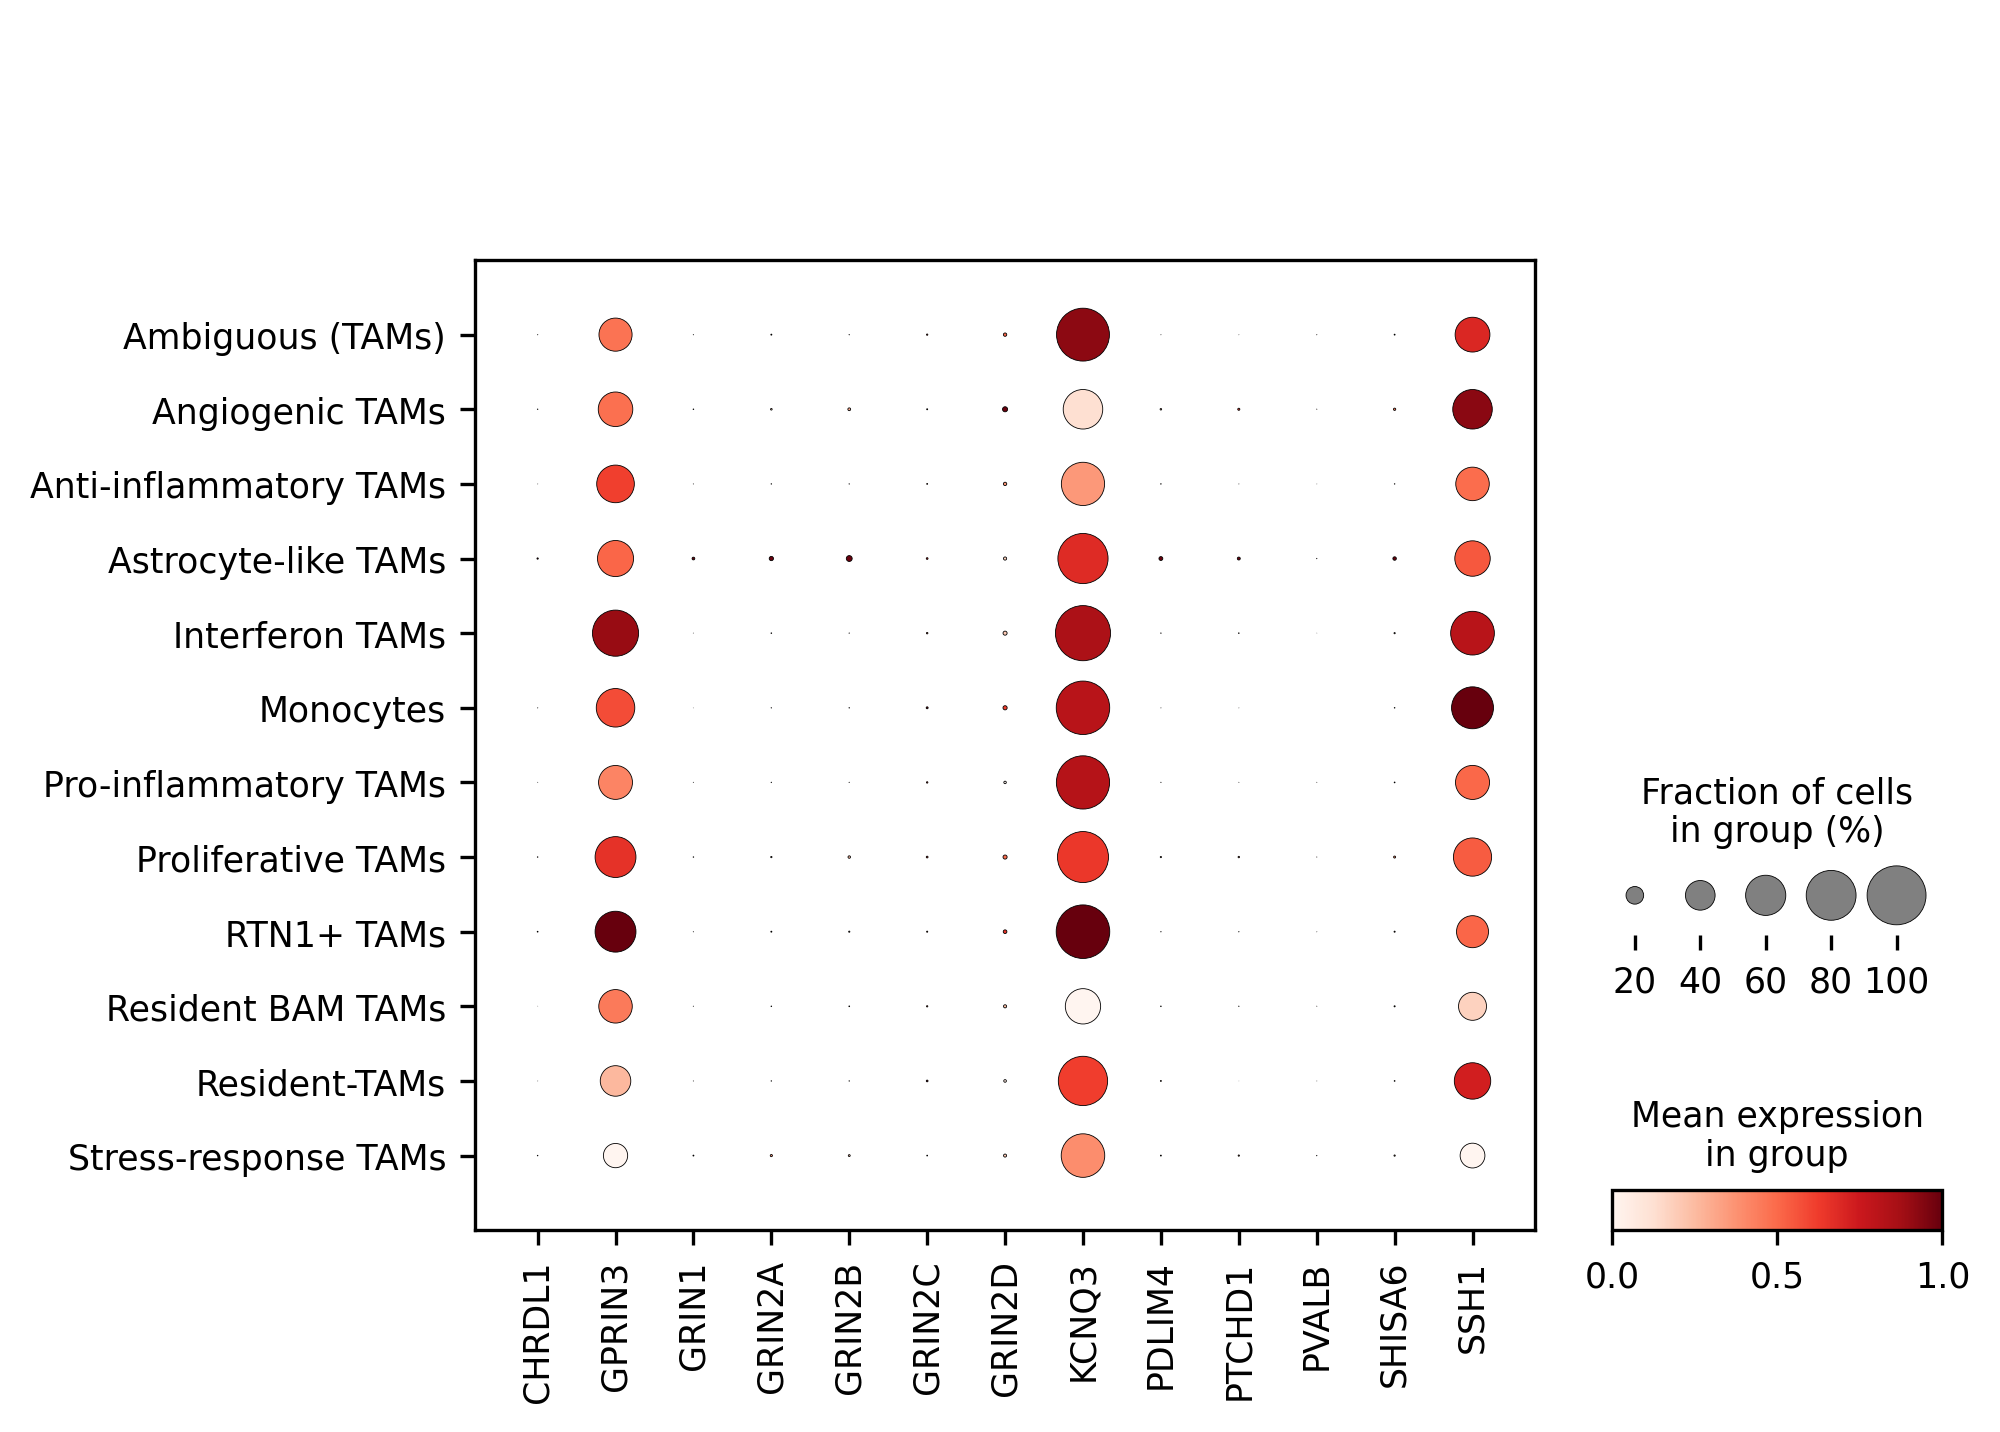

In [ ]:
selected_set = 'GOBP_EXCITATORY_CHEMICAL_SYNAPTIC_TRANSMISSION'
gs_genes = net[net['geneset']==selected_set]['genesymbol'].tolist()
gs_genes = [i for i in gs_genes if i in adata.var_names]
sc.pl.dotplot(adata, gs_genes, 'annotation_granular', standard_scale = 'var')

In [ ]:
t = deg[(deg['group']==ct) & (deg['names'].isin(gs_genes))]
len(t[(t['pvals']<0.05) & (t['scores']>0)])/len(gs_genes)

0.15384615384615385

In [ ]:
ct = cell_states[8]
print(ct)
t = (gsea_results_all[ct][(gsea_results_all[ct]['pval']<=0.05) &
(gsea_results_all[ct]['norm']>0)])
#[t.index.str.contains('angio', case= False)]
t[t.index.str.contains('differ', case=False)].head(200).style
#t.head(100).style

Monocytes


,score,norm,pval
source,,,
GOBP_CARDIOBLAST_DIFFERENTIATION,0.951927,1.493892,0.009868
GOBP_MYELOID_LEUKOCYTE_DIFFERENTIATION,0.604625,1.468134,0.011905
GOBP_REGULATION_OF_MYELOID_CELL_DIFFERENTIATION,0.599400,1.442953,0.013382
GOBP_MACROPHAGE_DIFFERENTIATION,0.765057,1.536973,0.015337
GOBP_MAMMARY_GLAND_EPITHELIAL_CELL_DIFFERENTIATION,0.844559,1.523085,0.018405
GOBP_HAIR_CELL_DIFFERENTIATION,0.756665,1.514416,0.019062
GOBP_CARDIOCYTE_DIFFERENTIATION,0.601858,1.425759,0.023661
GOBP_NEGATIVE_REGULATION_OF_MYELOID_CELL_DIFFERENTIATION,0.666050,1.420918,0.034632
GOBP_LUNG_CELL_DIFFERENTIATION,0.785686,1.464688,0.039809


In [ ]:
selected_pathways = [
    'GOBP_REGULATION_OF_ASTROCYTE_DIFFERENTIATION', #GOBP_SYNAPSE_PRUNING # microglia
    'GOBP_GLIAL_CELL_DEVELOPMENT', # ac-like
    'GOBP_INTERLEUKIN_2_PRODUCTION',
    'GOBP_TYPE_II_INTERFERON_PRODUCTION',
    'GOBP_CENTROSOME_DUPLICATION',
    'GOBP_VASCULAR_PROCESS_IN_CIRCULATORY_SYSTEM', #DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_VASCULAR_SMOOTH_MUSCLE_CELLS
    'GOBP_NEGATIVE_REGULATION_OF_INFLAMMATORY_RESPONSE',
    'TRAVAGLINI_LUNG_CLASSICAL_MONOCYTE_CELL', #TRAVAGLINI_LUNG_CLASSICAL_MONOCYTE_CELL
    'GOBP_MACROPHAGE_DIFFERENTIATION',
    'HALLMARK_FATTY_ACID_METABOLISM',
    'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
    'HALLMARK_HYPOXIA',
    'GOBP_BLOOD_VESSEL_ENDOTHELIAL_CELL_PROLIFERATION_INVOLVED_IN_SPROUTING_ANGIOGENESIS'
]

In [ ]:
filtered_pathway_df = []
for ct in gsea_results_all:
    res = gsea_results_all[ct][gsea_results_all[ct].index.isin(selected_pathways)].copy()
    res['state'] = ct
    filtered_pathway_df.append(res)
filtered_pathway_df = pd.concat(filtered_pathway_df).reset_index()

p_floor = 1 / (1000 + 1)

filtered_pathway_df["pval_plot"] = (
    filtered_pathway_df["pval"]
    .clip(lower=p_floor)
)
filtered_pathway_df["ng_log_p"] = -np.log(
    filtered_pathway_df["pval_plot"]
)

In [ ]:
filtered_pathway_df["state"] = pd.Categorical(
    filtered_pathway_df["state"],
    categories=cell_states,
    ordered=True
)

filtered_pathway_df["source"] = pd.Categorical(
    filtered_pathway_df["source"],
    categories=selected_pathways,
    ordered=True
)

filtered_pathway_df = filtered_pathway_df[filtered_pathway_df['pval']<=0.2]

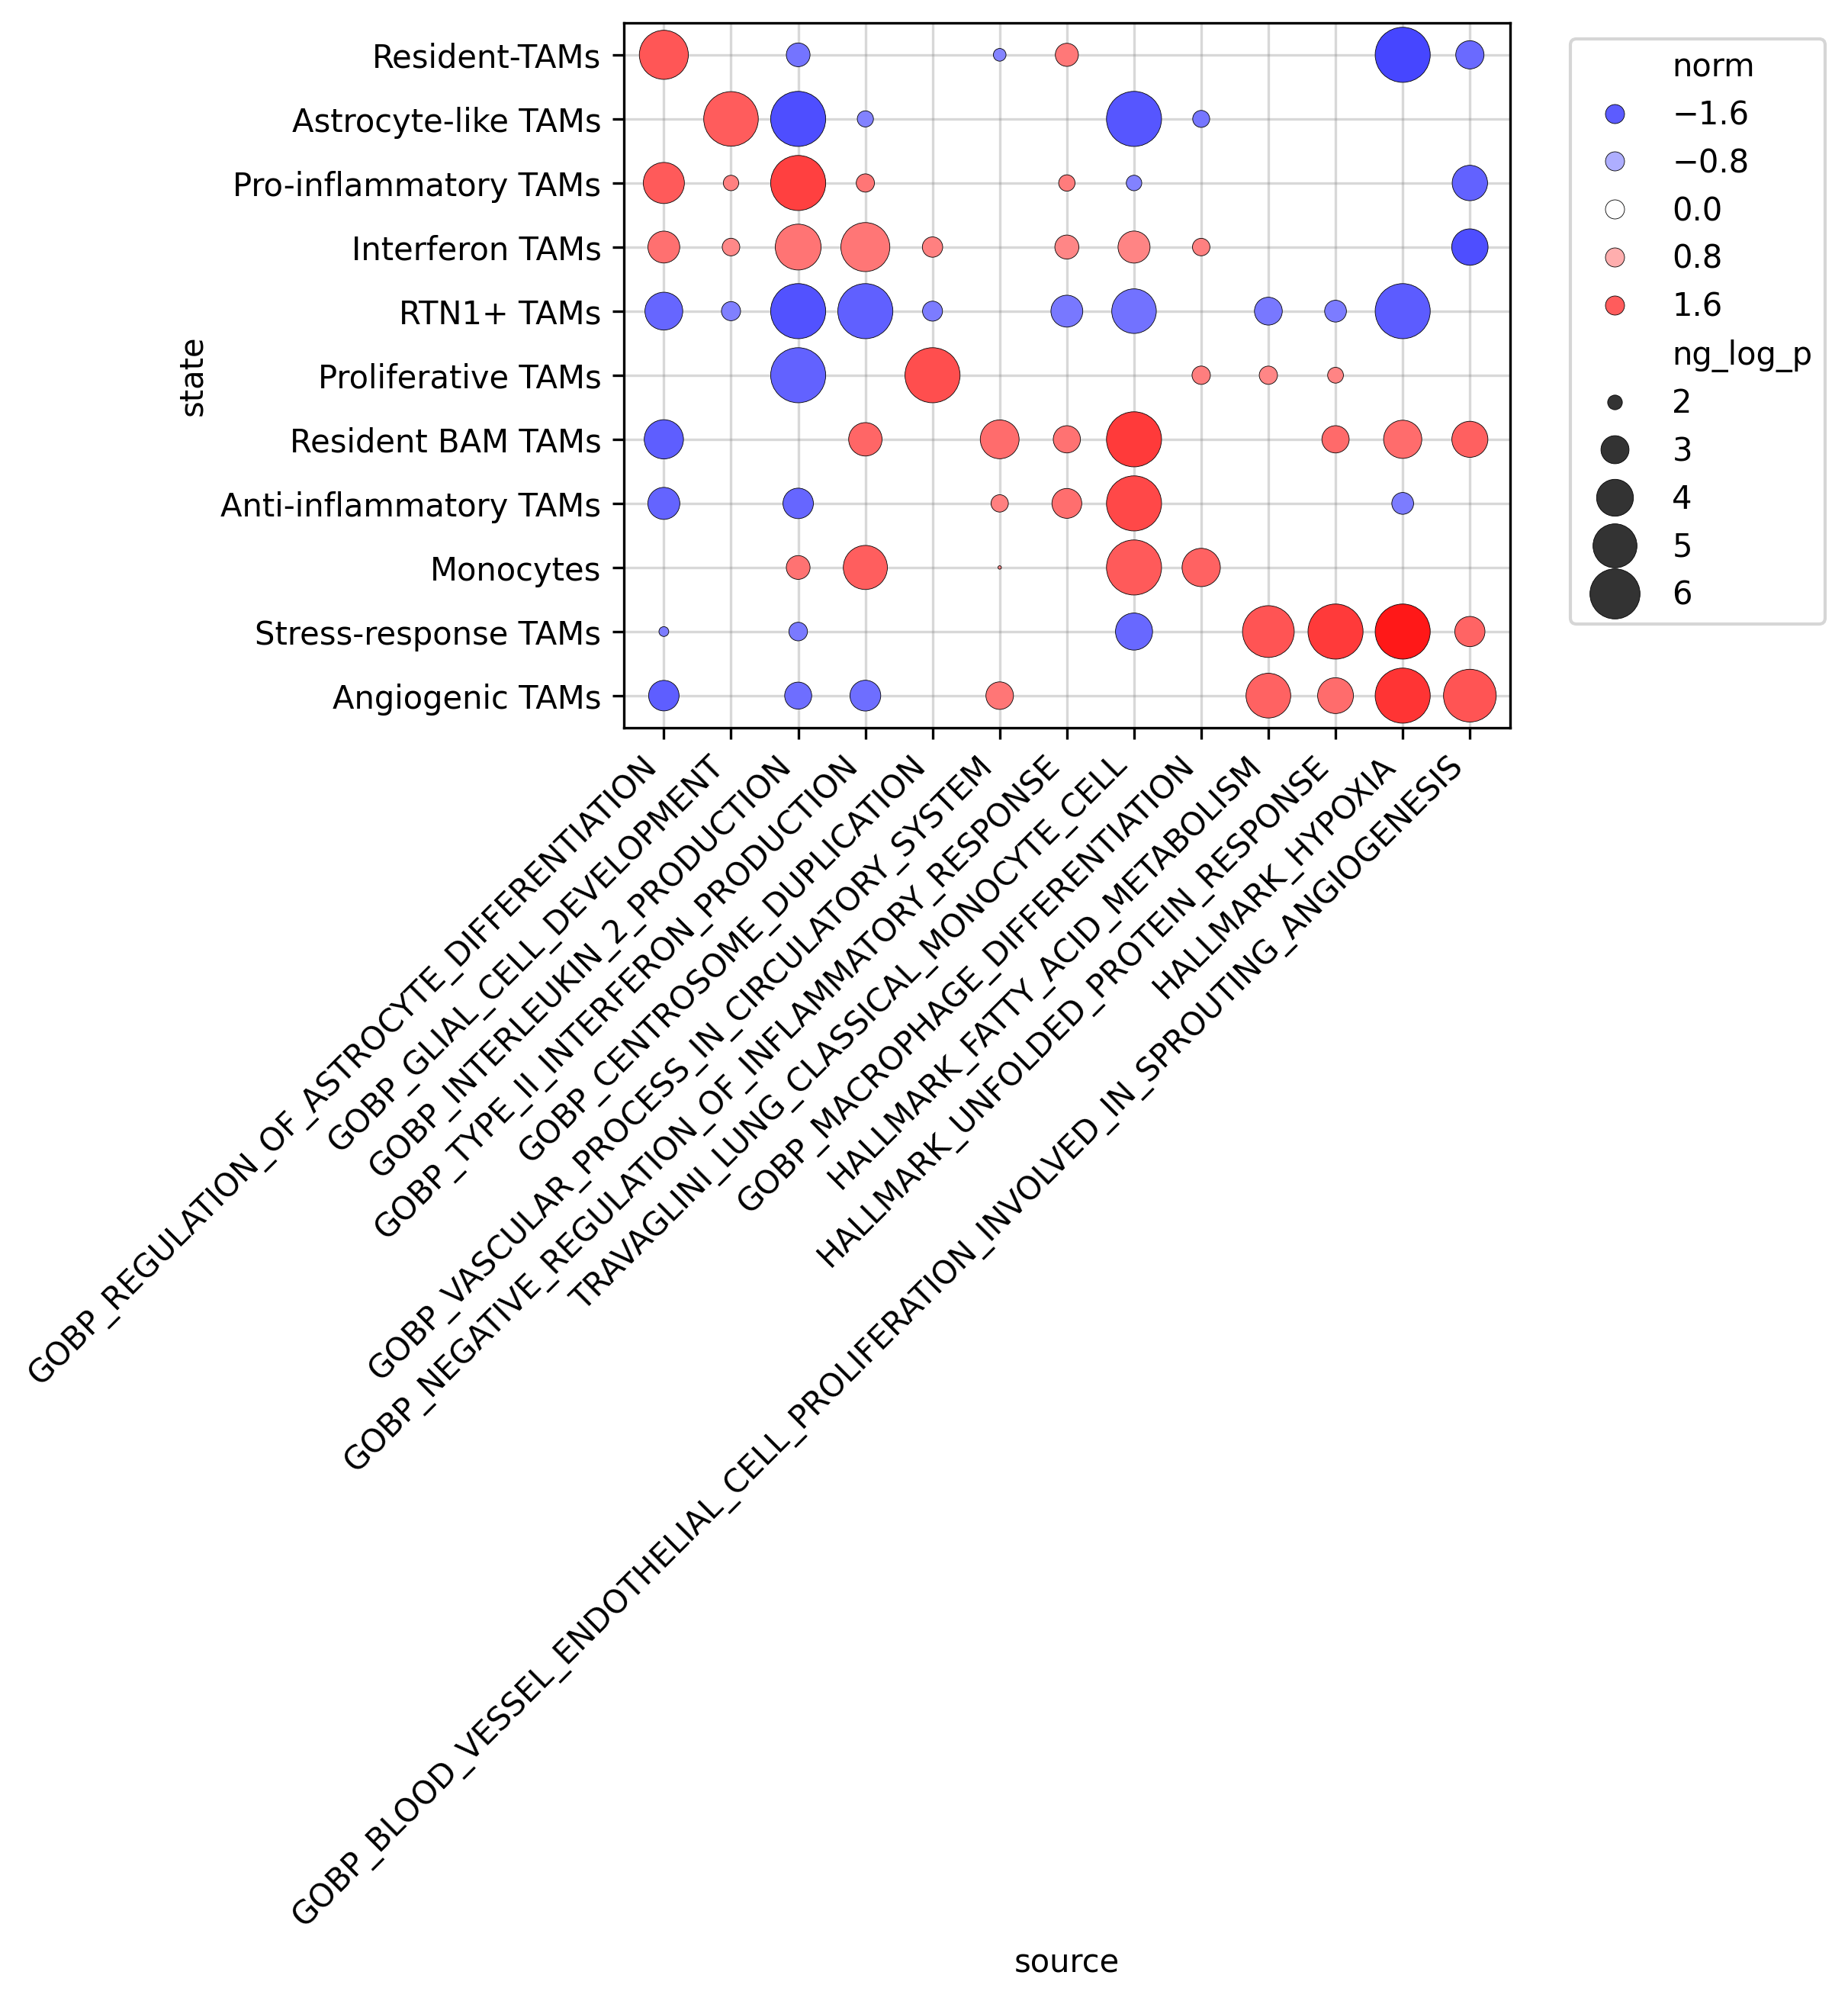

In [ ]:
plt.figure(figsize=(5, 4))
ax = sns.scatterplot(data = filtered_pathway_df, y = 'state', x = 'source',
                hue = 'norm', size = 'ng_log_p', 
                linewidth = 0.2, edgecolor = 'black',
                palette = 'bwr', #'RdBu_r', 
                sizes=(0, 300), hue_norm = (-2.5, 2.5))
plt.xticks(rotation=45, ha="right")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
ax.grid(True, color="grey", alpha=0.3, zorder=-1)
ax.set_axisbelow(True)
plt.savefig('../data/myeloid/EDFig10a4.pdf')
filtered_pathway_df.to_csv(f'{output_dir}/EDFig10a4.csv')